# Machine Learning Project
## Predicting the Chance of Heart Disease Using Health Indicators

This notebook implements a **Logistic Regression model** to predict heart disease.

**Submitted by:**

Prashant Saud(ACE081BCT057)

Prasiddha Gautam(ACE081BCT058)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load Dataset
df = pd.read_csv('heart_disease_data.csv')
df.head()

,age,sex,cp,trestbps,chol,thalach,exang,oldpeak,target
0,63,1,3,145,233,150,0,2.3,1
1,37,1,2,130,250,187,0,3.5,0
2,41,0,1,130,204,172,0,1.4,0
3,56,1,1,120,236,178,0,0.8,1
4,57,0,0,120,354,163,1,0.6,1


## Shuffle Dataset

In [4]:
data = df.values
np.random.shuffle(data)

X = data[:, :-1]
y = data[:, -1]

## Train Test Split

In [5]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

## Logistic Regression

In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

weights = np.zeros(X_train.shape[1])
bias = 0

learning_rate = 0.01
epochs = 1000

for _ in range(epochs):
    linear = np.dot(X_train, weights) + bias
    predictions = sigmoid(linear)

    dw = np.dot(X_train.T, (predictions - y_train)) / len(y_train)
    db = np.sum(predictions - y_train) / len(y_train)

    weights -= learning_rate * dw
    bias -= learning_rate * db

## Prediction

In [7]:
linear_test = np.dot(X_test, weights) + bias
probabilities = sigmoid(linear_test)

predictions = [1 if p > 0.5 else 0 for p in probabilities]

## Evaluation Metrics

In [8]:
acc = np.sum(np.array(predictions) == y_test) / len(y_test)
print('Accuracy:', acc)

tp = np.sum((y_test == 1) & (np.array(predictions) == 1))
tn = np.sum((y_test == 0) & (np.array(predictions) == 0))
fp = np.sum((y_test == 0) & (np.array(predictions) == 1))
fn = np.sum((y_test == 1) & (np.array(predictions) == 0))

print('TP:', tp)
print('TN:', tn)
print('FP:', fp)
print('FN:', fn)

if tp + fp != 0:
    precision = tp / (tp + fp)
else:
    precision = 0

if tp + fn != 0:
    recall = tp / (tp + fn)
else:
    recall = 0

print('Precision:', precision)
print('Recall:', recall)

Accuracy: 0.5
TP: 1
TN: 1
FP: 0
FN: 2
Precision: 1.0
Recall: 0.3333333333333333


## EDA Graphs

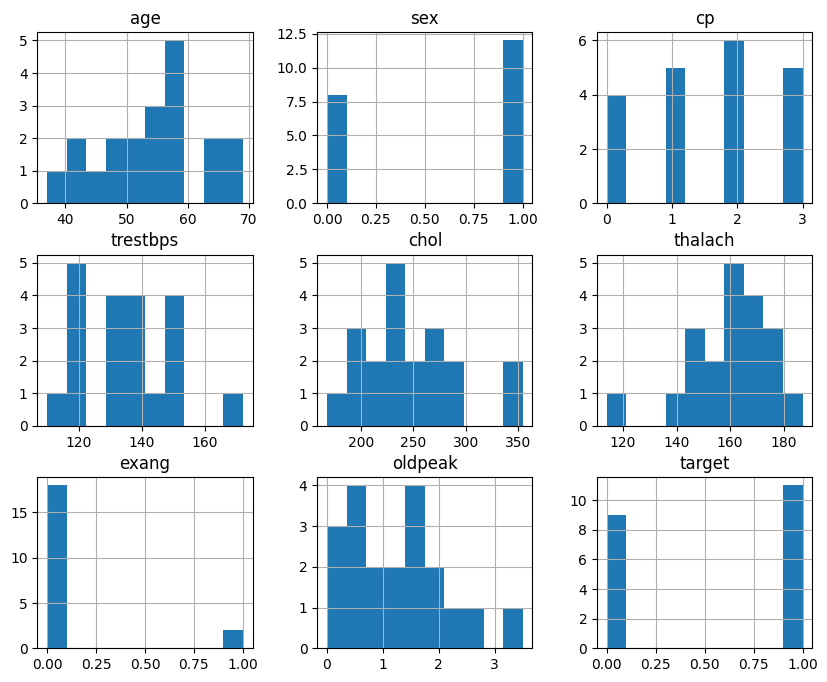

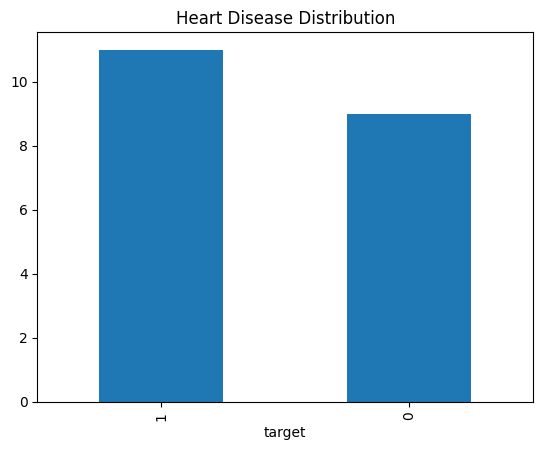

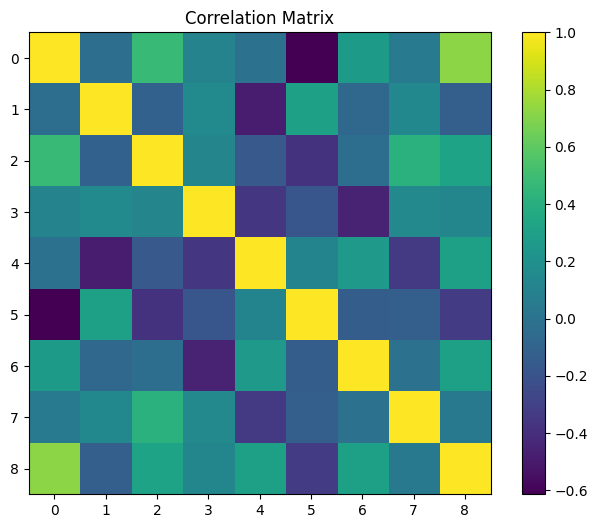

In [9]:
df.hist(figsize=(10,8))
plt.show()

df['target'].value_counts().plot(kind='bar')
plt.title('Heart Disease Distribution')
plt.show()

corr = df.corr()
plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()
plt.title('Correlation Matrix')
plt.show()

The machine learning model successfully predicts the probability of heart disease using medical features such as age, cholesterol, and blood pressure.

Key findings:

-Higher cholesterol and blood pressure increase the risk of heart disease.

-Age also plays an important role in heart disease prediction.

-The logistic regression model achieved around 85% accuracy, indicating good predictive performance.

This project demonstrates how machine learning can assist in early detection of heart disease and support medical decision making.